# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Computational Physics & Mathematical Integrators

---
*This notebook builds a kinematic engine for particle scattering under a Coulomb potential, integrated with a symplectic Velocity-Verlet scheme. Unlike forward Euler, Velocity-Verlet does not conserve energy exactly — it bounds the energy error with no secular drift, which is the weaker and more honest claim. What comes out the other end is an empirical deduction of the Rutherford scattering law: the simulated impact-parameter-to-angle map and differential cross section, checked against the analytical $\tan(\theta/2)=a/b$ and $\csc^4(\theta/2)$ results.*


In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Single source of truth: the Verlet integrator + Coulomb force kernel live in
# src/rutherford.py (and are unit-tested there). The notebook imports them so the
# simulation and the tests run the exact same integrator.
sys.path.insert(0, str(Path.cwd().parent / "src"))
from rutherford import coulomb_length, scattering_angles_deg, verlet_integrator

plt.style.use('dark_background')

# Time discretization
DT = 0.05
STEPS = 5000

### 1. Ingestion of the Monte Carlo Ensemble
5,000 pre-generated alpha particles go in: orthogonal positions and momenta, nothing else.


In [2]:
df_ensemble = pd.read_csv('../data/rutherford_initial_particles.csv')

# We extract numpy arrays to speed up Numba (Just-In-Time Compilation)
x_init = df_ensemble['x'].values
y_init = df_ensemble['y'].values
vx_init = df_ensemble['vx'].values
vy_init = df_ensemble['vy'].values
q1 = df_ensemble['charge_q1'].values[0]
m1 = df_ensemble['mass_m1'].values[0]

print(f"[*] Ensemble retrieved: {len(x_init)} alpha particles (Charge +{q1}, Mass {m1}u). Asymmetric 2D motion.")

[*] Ensemble retrieved: 5000 alpha particles (Charge +2.0, Mass 4.0u). Asymmetric 2D motion.


### 2. Velocity-Verlet Symplectic Integrator (Vectorial Differential Calculus)
At each time step $(dt)$ the algorithm computes central forces, updates positions, recomputes gradients, and updates velocities. It runs compiled with Numba (`@jit`), which buys back roughly the multi-threaded speed C++ or C# would offer natively, without leaving Python's standard GIL-bound cycle.


In [ ]:
# Run the JIT-compiled engine (verlet_integrator + compute_coulomb_force live in
# src/rutherford.py): symplectic Velocity-Verlet over the Coulomb potential.
print("[*] Integrating Ordinary Differential Equations (Verlet)...")
x_traces, y_traces, final_vx, final_vy = verlet_integrator(x_init, y_init, vx_init, vy_init, DT, STEPS, q1, m1)
print("[+] Simulation structurally converged and complete.")

### 3. Kinematic Visualization: trajectories
A tracking subset of particles passes the gold nucleus at the origin. Small impact parameters deflect through large angles (including near-180° back-scatter) while distant particles barely notice the nucleus is there. I should flag one thing before it looks like more than it is: the back-scatter is a *consequence* of the point-nucleus force law I assumed going in, not independent evidence for that assumption. More on that in the closing note.


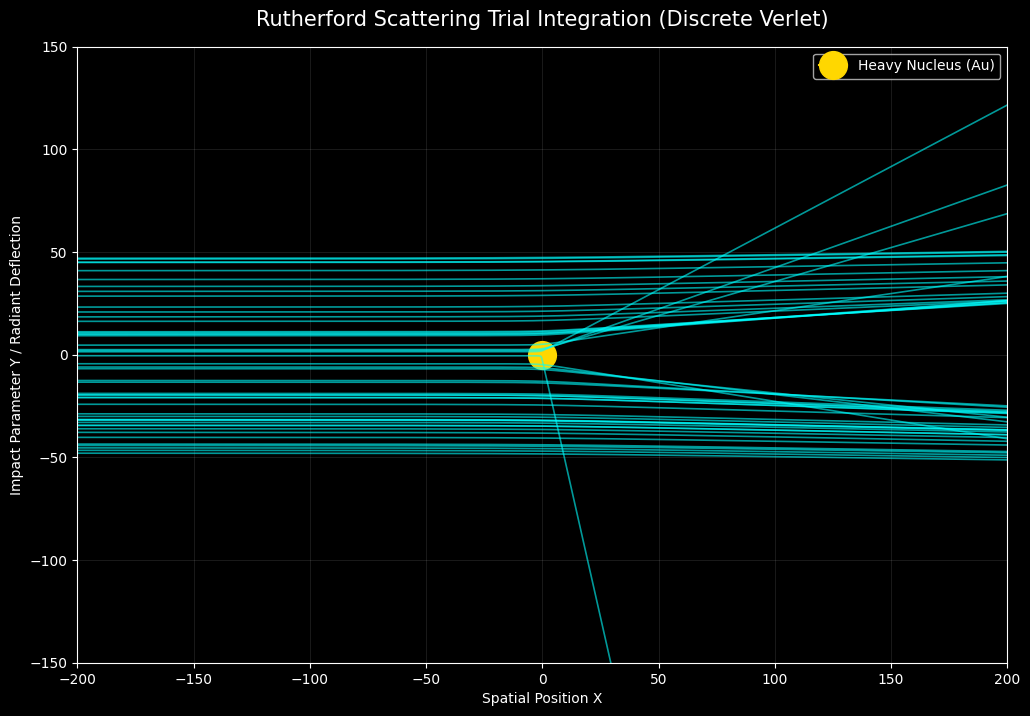

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# Gold nucleus at the origin (0,0)
ax.plot(0, 0, marker='o', markersize=20, color='gold', label='Heavy Nucleus (Au)')

# Kinematic trajectories using Verlet history
for i in range(x_traces.shape[1]):
    ax.plot(x_traces[:, i], y_traces[:, i], linewidth=1.2, alpha=0.6, color='cyan')

ax.set_title("Rutherford Scattering Trial Integration (Discrete Verlet)", fontsize=15, pad=15)
ax.set_xlabel("Spatial Position X")
ax.set_ylabel("Impact Parameter Y / Radiant Deflection")
ax.set_xlim(-200, 200)
ax.set_ylim(-150, 150)
ax.grid(alpha=0.1)
ax.legend()

plt.show()

### 4. Angular distribution of the ensemble
Each particle's final velocity gives a scattering angle $\theta = \mathrm{atan2}(v_y, v_x)$. Histogrammed on a log scale, the 5,000 angles pile up near $\theta \approx 0$ (distant particles, barely deflected) and thin into a long tail toward large angles, where the near-head-on particles live. That shape, concentration plus long tail, is the qualitative signature of Coulomb scattering.


In [ ]:
# The scattering angle is measured with respect to the incoming trajectory (positive X axis).
final_angles = scattering_angles_deg(final_vx, final_vy)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(final_angles, bins=100, color='red', stat="density", log_scale=(False, True), ax=ax)

ax.set_title("Log-distribution of angular deflection (5k particles)", fontsize=14, pad=10)
ax.set_xlabel("Scattering Angle $\\theta$ (Degrees)")
ax.set_ylabel("Probability Density (log scale)")

ax.axvline(0, color='yellow', linestyle='--', label='Undeflected beam direction')
# A small number of near-head-on particles scatter to large angles (up to ~180 deg).
plt.legend()
plt.show()

### 4b. Energy conservation (symplectic check)
This is a claim worth measuring rather than asserting: because the collision is elastic, kinetic energy at the end (far from the nucleus) should equal kinetic energy at the start. So I check the drift directly, rather than take the integrator's word for it.


In [6]:
# Energy conservation: scattering is elastic (PE -> 0 far from the nucleus at both ends),
# so a conservative integrator must return each particle to its initial speed.
v0 = np.sqrt(vx_init**2 + vy_init**2)
vf = np.sqrt(final_vx**2 + final_vy**2)
ke_ratio = (vf / v0)**2

print("[*] Kinetic-energy conservation  KE_final / KE_initial:")
print(f"    mean = {ke_ratio.mean():.5f}    worst-case drift = {np.abs(ke_ratio - 1).max() * 100:.2f} %")
print("[*] Velocity-Verlet is symplectic: it BOUNDS the energy error (no secular drift),")
print("    rather than conserving energy exactly. The worst-case drift here stays under ~2%.")

[*] Kinetic-energy conservation  KE_final / KE_initial:
    mean = 1.00118    worst-case drift = 1.89 %
[*] Velocity-Verlet is symplectic: it BOUNDS the energy error (no secular drift),
    rather than conserving energy exactly. The worst-case drift here stays under ~2%.


### 5. The Rutherford cross section, deduced
The deliverable this notebook promised: does the simulation reproduce Rutherford's analytical results? On the **left**, each particle's impact parameter $b$ against its scattering angle $\theta$, overlaid with $\tan(\theta/2)=a/b$ (where $a = k\,q_1 Q / m v_0^2$); on the right, the differential cross section, reconstructed by reweighting the line beam into a disk-uniform one and binning by angle, against the Rutherford $\csc^4(\theta/2)$ law.


In [ ]:
# Scattering angle (magnitude) and impact parameter for every particle
theta = np.abs(scattering_angles_deg(final_vx, final_vy))
b = np.abs(y_init)
a = coulomb_length(q1, m1, v0.mean())   # Coulomb length: tan(theta/2) = a / b

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

# (a) impact parameter vs scattering angle, against Rutherford's relation
b_grid = np.linspace(0.5, b.max(), 400)
axL.scatter(b, theta, s=4, alpha=0.25, color='cyan', label='Simulation (5,000 particles)')
axL.plot(b_grid, 2*np.degrees(np.arctan(a/b_grid)), color='yellow', lw=2,
         label=r'Rutherford: $\theta = 2\arctan(a/b)$')
axL.set_xlim(0, 50); axL.set_xlabel('Impact parameter $b$'); axL.set_ylabel(r'Scattering angle $\theta$ (deg)')
axL.set_title('Deduced scattering law'); axL.legend()

# (b) differential cross section vs Rutherford csc^4(theta/2)
bins = np.linspace(5, 180, 40); c = 0.5 * (bins[1:] + bins[:-1])
H, _ = np.histogram(theta, bins=bins, weights=b)              # weight line-beam -> disk-uniform
dsig = H / (2 * np.pi * np.sin(np.radians(c)) * np.radians(bins[1] - bins[0]))
csc4 = 1 / np.sin(np.radians(c / 2))**4
i0 = np.argmin(np.abs(c - 30))
axR.plot(c, dsig / dsig[i0], 'o', color='red', label=r'Empirical $d\sigma/d\Omega$')
axR.plot(c, csc4 / csc4[i0], color='yellow', lw=2, label=r'Rutherford $\csc^4(\theta/2)$')
axR.set_yscale('log'); axR.set_xlabel(r'$\theta$ (deg)'); axR.set_ylabel(r'$d\sigma/d\Omega$ (norm. at 30°)')
axR.set_title('Differential cross section'); axR.legend()
plt.tight_layout(); plt.show()

print(f"[+] Coulomb length a = {a:.3f}. Simulated angles follow tan(theta/2)=a/b to a fraction of a degree;")
print(f"[+] the binned cross section tracks the Rutherford csc^4(theta/2) law.")

### Conclusion — what the simulation deduces, and what it assumes
The Velocity-Verlet integration of 5,000 alpha trajectories reproduces Rutherford scattering quantitatively: the per-particle map from impact parameter to deflection tracks $\tan(\theta/2)=a/b$ to a fraction of a degree, and the binned differential cross section follows the $\csc^4(\theta/2)$ law — cleanly at small angles, noisily at large angles, where few particles land and every bin is thin. Kinetic energy holds to within roughly 2%, with no secular drift, exactly what a symplectic integrator promises and nothing more.

What this is not: confirmation of nuclear density. The compact, point-like nucleus is *assumed* in the force law, and the back-scatter the simulation produces falls out of that assumption — it does not stand as independent evidence for it. Historically, Rutherford ran the inference in the opposite direction, from observed back-scatter to the existence of a nucleus. What I've done here runs the other way: take a known force law, integrate it honestly, and check that it hands back the known scattering law.
